In [43]:
%pip install seaborn

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("auto sales cleaned.csv")
df.head()

,ordernumber,quantityordered,priceeach,orderlinenumber,sales,orderdate,days_since_lastorder,status,productline,msrp,...,contactlastname,contactfirstname,dealsize,year,month,month_name,quarter,year_month,discount_amount,percent_discount
0,10107,30,95.70,2,2871.00,2018-02-24,828,Shipped,Motorcycles,95,...,Yu,Kwai,Small,2018,2,February,1,2018-02,-0.70,-0.74
1,10121,34,81.35,5,2765.90,2018-05-07,757,Shipped,Motorcycles,95,...,Henriot,Paul,Small,2018,5,May,2,2018-05,13.65,14.37
2,10134,41,94.74,2,3884.34,2018-07-01,703,Shipped,Motorcycles,95,...,Da Cunha,Daniel,Medium,2018,7,July,3,2018-07,0.26,0.27
3,10145,45,83.26,6,3746.70,2018-08-25,649,Shipped,Motorcycles,95,...,Young,Julie,Medium,2018,8,August,3,2018-08,11.74,12.36
4,10168,36,96.66,1,3479.76,2018-10-28,586,Shipped,Motorcycles,95,...,Hirano,Juri,Medium,2018,10,October,4,2018-10,-1.66,-1.75


In [4]:
##size
df.shape

(2747, 27)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ordernumber           2747 non-null   int64  
 1   quantityordered       2747 non-null   int64  
 2   priceeach             2747 non-null   float64
 3   orderlinenumber       2747 non-null   int64  
 4   sales                 2747 non-null   float64
 5   orderdate             2747 non-null   str    
 6   days_since_lastorder  2747 non-null   int64  
 7   status                2747 non-null   str    
 8   productline           2747 non-null   str    
 9   msrp                  2747 non-null   int64  
 10  productcode           2747 non-null   str    
 11  customername          2747 non-null   str    
 12  phone                 2747 non-null   str    
 13  addressline1          2747 non-null   str    
 14  city                  2747 non-null   str    
 15  postalcode            2747 non-n

In [6]:
##total_sales
total_sales = df["sales"].sum()

##average sales
average_sales = df["sales"].mean()

##median sales
median_sales = df["sales"].median()

##total quantity sold
total_quantity = df["quantityordered"].sum()


print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Sales: ${median_sales:,.2f}")
print(f"Median Sales per Order Line: ${average_sales:,.2f}")






Total Sales: $9,760,221.71
Total Quantity Sold: 96,428
Average Sales: $3,184.80
Median Sales per Order Line: $3,553.05


In [9]:
##number of customers
total_customers = df["customername"].nunique()

##number of products
unique_products = df["productcode"].nunique()

print(f"Total customers: {total_customers:,}")
print(f"Unique Products: {unique_products:,}")

Total customers: 89
Unique Products: 109


In [15]:
## KPI summary
summary = pd.DataFrame({
    "Total Sales" : total_sales,
    "Total Quantity Sold" : total_quantity,
    "Average Sales": average_sales,
    "Median Sales" : median_sales,
    "Total Customers": total_customers,
    "Unique Products": unique_products
    
}, index= [0]) 
summary

,Total Sales,Total Quantity Sold,Average Sales,Median Sales,Total Customers,Unique Products
0,9760221.71,96428,3553.047583,3184.8,89,109


In [23]:
##sales by year
sales_by_year = df.groupby("year")["sales"].sum().reset_index().sort_values("year")
sales_by_year

,year,sales
0,2018,3353014.06
1,2019,4669924.56
2,2020,1737283.09


In [20]:
sales_by_year["growth_%"] = (
    sales_by_year["sales"].pct_change() * 100
)

sales_by_year

,year,sales,growth_%
0,2018,3353014.06,NaN
1,2019,4669924.56,39.275424
2,2020,1737283.09,-62.798476


In [28]:
##monthly sales
sales_by_month = df.groupby("month")["sales"].sum().reset_index()
sales_by_month = sales_by_month.sort_values("month")
sales_by_month


,month,sales
0,1,761985.12
1,2,756238.28
2,3,735805.81
3,4,669390.96
4,5,923972.56
5,6,454756.78
6,7,514875.97
7,8,659310.57
8,9,584724.27
9,10,1001377.20


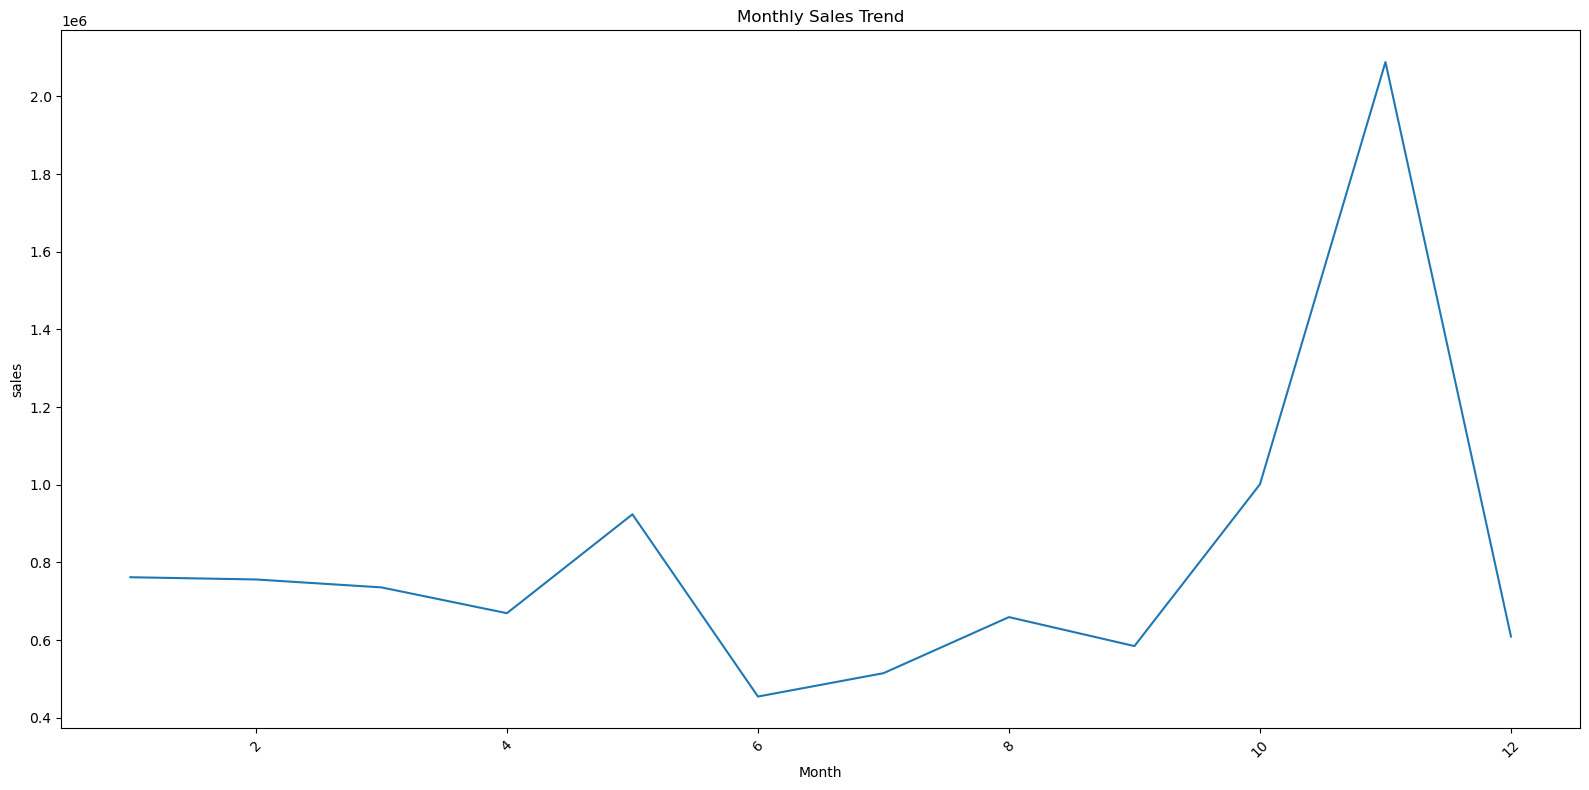

In [34]:
##sales by month visualization
plt.figure(figsize = (16,8))
plt.plot(
    sales_by_month["month"],
    sales_by_month["sales"]
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
##quartely sales
quaterly_sales = df.groupby(["year","quarter"])["sales"].sum().reset_index()
quaterly_sales

,year,quarter,sales
0,2018,1,426399.11
1,2018,2,562365.22
2,2018,3,649514.54
3,2018,4,1714735.19
4,2019,1,809841.36
5,2019,2,766260.73
6,2019,3,1109396.27
7,2019,4,1984426.20
8,2020,1,1017788.74
9,2020,2,719494.35


In [36]:
df["year_quarter"] = (
    df["year"].astype(str) +
    "-Q" +
    df["quarter"].astype(str)
)

quarterly_sales = (
    df.groupby("year_quarter")["sales"]
      .sum()
      .reset_index()
)

quarterly_sales

,year_quarter,sales
0,2018-Q1,426399.11
1,2018-Q2,562365.22
2,2018-Q3,649514.54
3,2018-Q4,1714735.19
4,2019-Q1,809841.36
5,2019-Q2,766260.73
6,2019-Q3,1109396.27
7,2019-Q4,1984426.20
8,2020-Q1,1017788.74
9,2020-Q2,719494.35


In [38]:
product_sales = df.groupby("productline")["sales"].sum().reset_index().sort_values("sales", ascending = False)
product_sales

,productline,sales
0,Classic Cars,3842868.54
6,Vintage Cars,1806675.68
5,Trucks and Buses,1111559.19
1,Motorcycles,1103512.19
2,Planes,969323.42
3,Ships,700039.22
4,Trains,226243.47


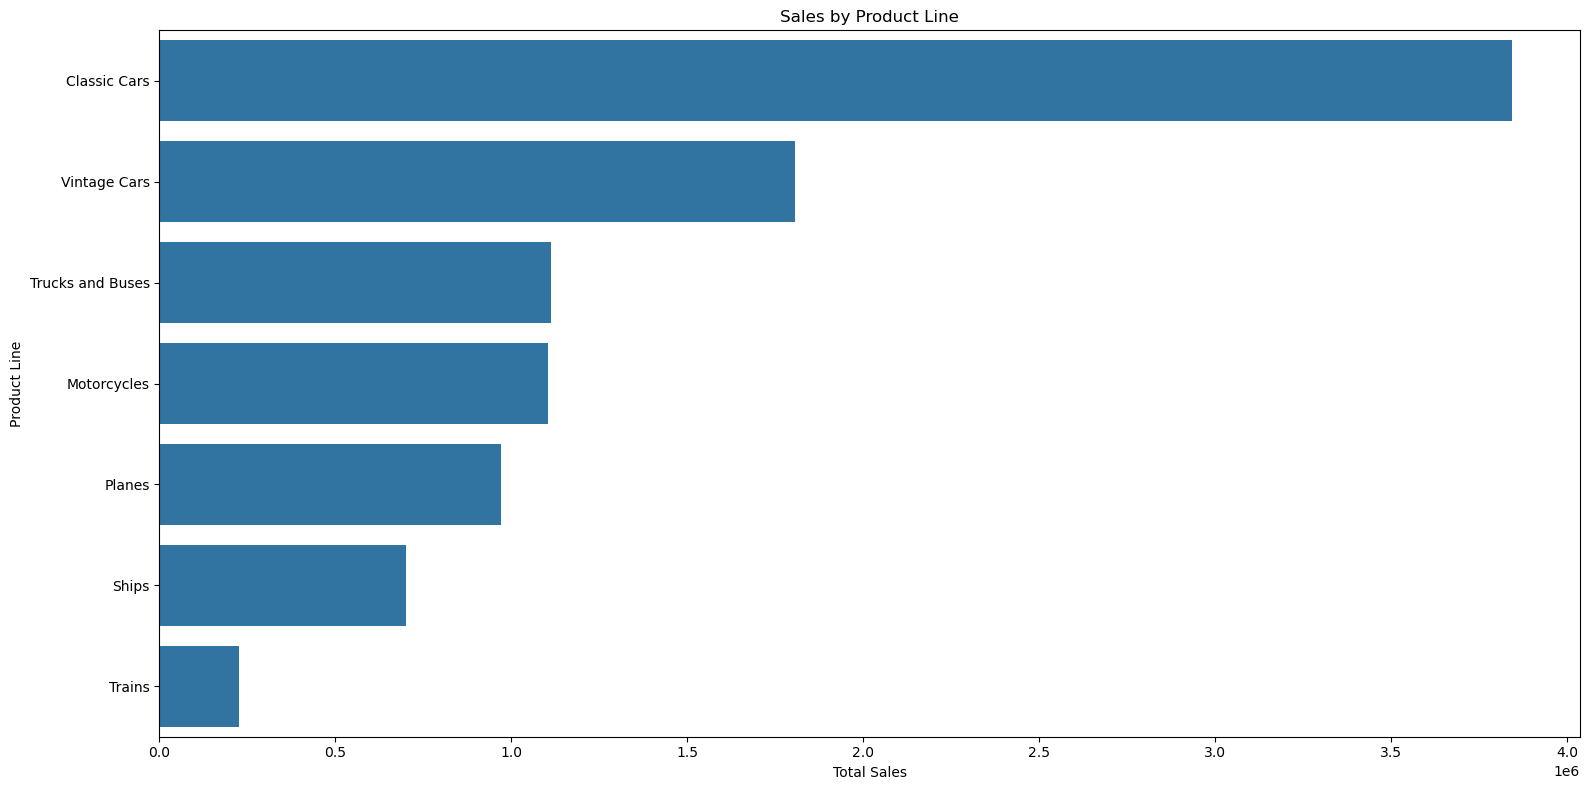

In [46]:
##visualization
plt.figure(figsize = (16,8))
sns.barplot(
    data = product_sales,
    x = "sales",
    y = "productline"
)
plt.title("Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")

plt.tight_layout()
plt.show()

In [47]:
product_quantity = df.groupby("productline")["quantityordered"].sum().reset_index().sort_values("quantityordered", ascending = False)
product_quantity

,productline,quantityordered
0,Classic Cars,33373
6,Vintage Cars,20059
1,Motorcycles,11080
2,Planes,10636
5,Trucks and Buses,10579
3,Ships,7989
4,Trains,2712


In [49]:
product_price = df.groupby("productline")["priceeach"].mean().reset_index().sort_values("priceeach", ascending = False)
product_price

,productline,priceeach
0,Classic Cars,115.195680
5,Trucks and Buses,104.344983
1,Motorcycles,99.767125
2,Planes,90.517829
6,Vintage Cars,90.011261
3,Ships,88.169261
4,Trains,84.108701


In [50]:
##product line summary
product_summary = (
    df.groupby("productline")
      .agg(
          total_sales=("sales", "sum"),
          total_quantity=("quantityordered", "sum"),
          average_price=("priceeach", "mean"),
          order_lines=("ordernumber", "count"),
          unique_orders=("ordernumber", "nunique")
      )
      .reset_index()
      .sort_values("total_sales", ascending=False)
)

product_summary

,productline,total_sales,total_quantity,average_price,order_lines,unique_orders
0,Classic Cars,3842868.54,33373,115.195680,949,193
6,Vintage Cars,1806675.68,20059,90.011261,579,169
5,Trucks and Buses,1111559.19,10579,104.344983,295,71
1,Motorcycles,1103512.19,11080,99.767125,313,70
2,Planes,969323.42,10636,90.517829,304,58
3,Ships,700039.22,7989,88.169261,230,63
4,Trains,226243.47,2712,84.108701,77,45


In [51]:
##deal summary
deal_summary = df.groupby("dealsize").agg(
    total_sales = ("sales","sum"),
    total_quantity = ("quantityordered", "sum"),
    average_sales = ("sales", "mean"),
    order_lines = ("ordernumber", "count")
).reset_index().sort_values("total_sales", ascending = False)
deal_summary

,dealsize,total_sales,total_quantity,average_sales,order_lines
1,Medium,5931231.47,51209,4396.761653,1349
2,Small,2570033.84,38025,2062.627480,1246
0,Large,1258956.40,7194,8282.607895,152


In [52]:
##sales by country
country_sales = (
    df.groupby("country")["sales"]
      .sum()
      .reset_index()
      .sort_values("sales", ascending=False)
)

country_sales.head(10)

,country,sales
18,USA,3355575.69
14,Spain,1215686.92
6,France,1110916.52
0,Australia,630623.10
17,UK,478880.46
9,Italy,374674.31
5,Finland,329581.91
11,Norway,307463.70
13,Singapore,288488.41
4,Denmark,245637.15


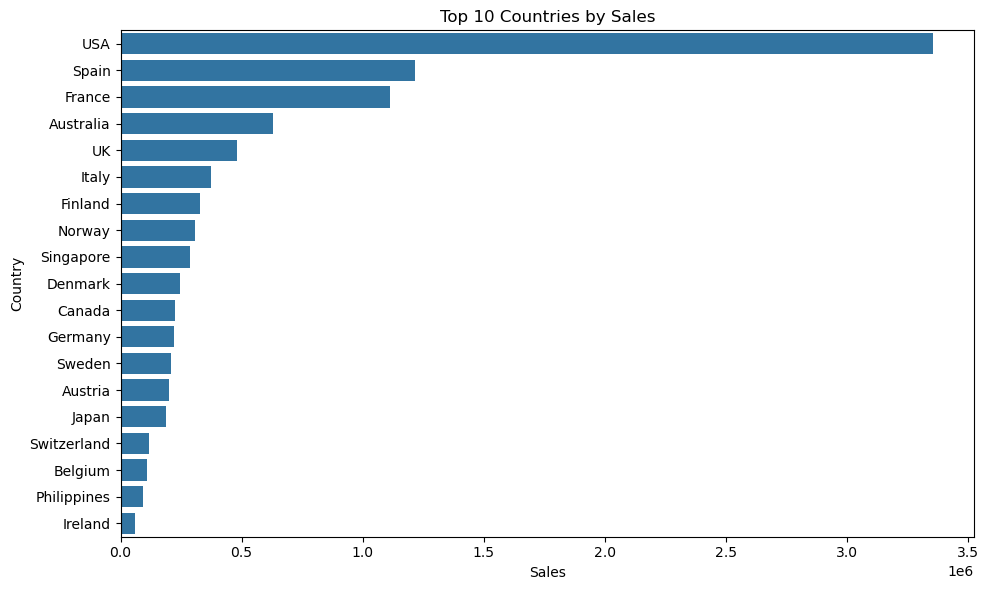

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_sales,
    x="sales",
    y="country"
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [60]:
##sales by city
city_sales = (
    df.groupby("city")["sales"]
      .sum()
      .reset_index()
      .sort_values("sales", ascending=False)
)

top_ten = city_sales.head(10)
top_ten

,city,sales
33,Madrid,1082551.44
59,San Rafael,654858.06
41,NYC,560787.77
61,Singapore,288488.41
51,Paris,268944.68
44,New Bedford,207874.86
42,Nantes,204304.86
37,Melbourne,200995.41
7,Brickhaven,165255.20
58,San Jose,160010.27


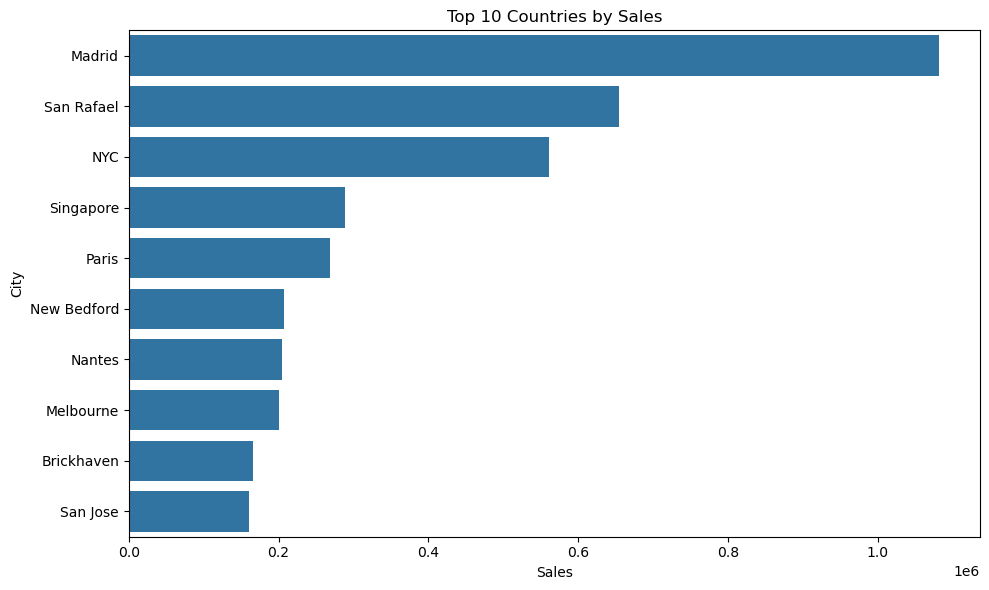

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_ten,
    x="sales",
    y="city"
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [62]:
customer_sales = (
    df.groupby("customername")["sales"]
      .sum()
      .reset_index()
      .sort_values("sales", ascending=False)
)

customer_sales.head(10)

,customername,sales
32,Euro Shopping Channel,912294.11
53,Mini Gifts Distributors Ltd.,654858.06
6,"Australian Collectors, Co.",200995.41
55,Muscle Machine Inc,197736.94
43,La Rochelle Gifts,180124.90
30,"Dragon Souveniers, Ltd.",172989.68
44,Land of Toys Inc.,164069.44
78,The Sharp Gifts Warehouse,160010.27
0,"AV Stores, Co.",157807.81
3,"Anna's Decorations, Ltd",153996.13


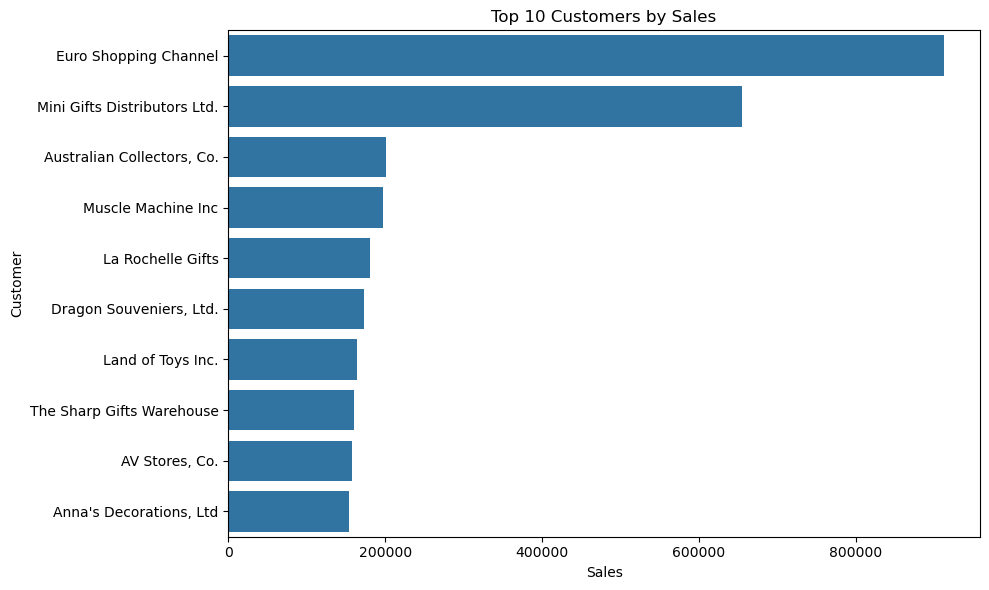

In [63]:
top_customers = customer_sales.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    x="sales",
    y="customername"
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

In [64]:
##customers order frequency
customer_orders = (
    df.groupby("customername")["ordernumber"]
      .nunique()
      .reset_index(name="number_of_orders")
      .sort_values("number_of_orders", ascending=False)
)

customer_orders.head(10)

,customername,number_of_orders
32,Euro Shopping Channel,26
53,Mini Gifts Distributors Ltd.,17
6,"Australian Collectors, Co.",5
30,"Dragon Souveniers, Ltd.",5
26,Danish Wholesale Imports,5
63,Reims Collectables,5
44,Land of Toys Inc.,4
76,Technics Stores Inc.,4
37,Handji Gifts& Co,4
55,Muscle Machine Inc,4


In [65]:
##summary
customer_summary = (
    df.groupby("customername")
      .agg(
          total_sales=("sales", "sum"),
          number_of_orders=("ordernumber", "nunique"),
          total_quantity=("quantityordered", "sum"),
          average_order_line_sales=("sales", "mean")
      )
      .reset_index()
      .sort_values("total_sales", ascending=False)
)

customer_summary.head(10)

,customername,total_sales,number_of_orders,total_quantity,average_order_line_sales
32,Euro Shopping Channel,912294.11,26,9327,3522.371081
53,Mini Gifts Distributors Ltd.,654858.06,17,6366,3638.100333
6,"Australian Collectors, Co.",200995.41,5,1926,3654.462000
55,Muscle Machine Inc,197736.94,4,1775,4119.519583
43,La Rochelle Gifts,180124.90,4,1832,3398.583019
30,"Dragon Souveniers, Ltd.",172989.68,5,1524,4023.015814
44,Land of Toys Inc.,164069.44,4,1631,3348.355918
78,The Sharp Gifts Warehouse,160010.27,4,1656,4000.256750
0,"AV Stores, Co.",157807.81,3,1778,3094.270784
3,"Anna's Decorations, Ltd",153996.13,4,1469,3347.741957


In [71]:
status_summary = (
    df.groupby("status")
      .agg(
          order_lines=("ordernumber", "count"),
          total_sales=("sales", "sum")
      )
      .reset_index()
      .sort_values("total_sales", ascending=False)
)

status_summary

,status,order_lines,total_sales
5,Shipped,2541,9019093.94
0,Cancelled,60,194487.48
3,On Hold,44,178979.19
4,Resolved,47,150718.28
2,In Process,41,144729.96
1,Disputed,14,72212.86


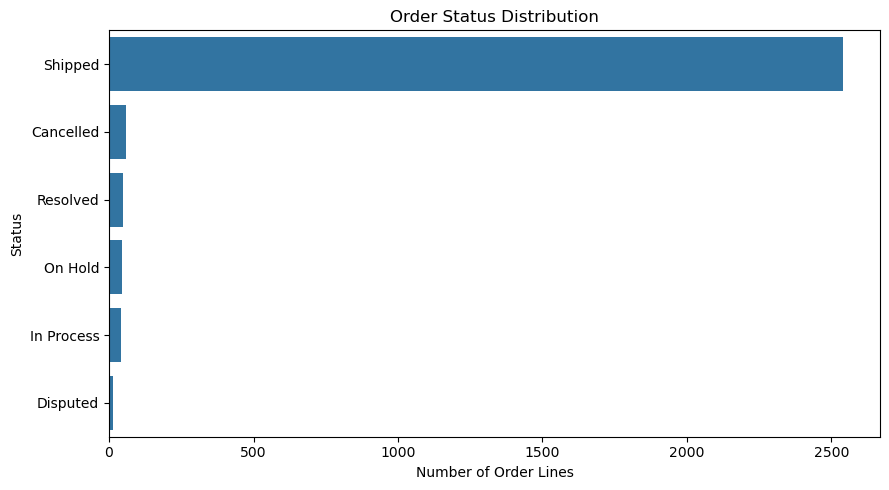

In [72]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    y="status",
    order=df["status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Order Lines")
plt.ylabel("Status")

plt.tight_layout()
plt.show()

In [74]:
df[
    [
        "msrp",
        "priceeach",
        "discount_amount",
        "percent_discount"
    ]
].describe()

,msrp,priceeach,discount_amount,percent_discount
count,2747.000000,2747.000000,2747.000000,2747.000000
mean,100.691664,101.098952,-0.407288,-4.038828
std,40.114802,42.042549,27.408186,38.099609
min,33.000000,26.880000,-219.870000,-666.270000
25%,68.000000,68.745000,-10.670000,-12.160000
50%,99.000000,95.550000,-0.360000,-0.400000
75%,124.000000,127.100000,10.330000,11.520000
max,214.000000,252.870000,154.640000,77.130000


In [76]:
average_discount = df["percent_discount"].mean()

print(
    f"Average discount relative to MSRP: "
    f"{average_discount:.2f}%"
)

Average discount relative to MSRP: -4.04%


In [79]:
##discount by product line
discount_by_product = (
    df.groupby("productline")["percent_discount"]
      .mean()
      .reset_index()
      .sort_values("percent_discount", ascending=False)
)

discount_by_product

,productline,percent_discount
0,Classic Cars,0.638282
2,Planes,-3.405724
5,Trucks and Buses,-4.025288
3,Ships,-4.093739
1,Motorcycles,-5.887444
6,Vintage Cars,-9.211261
4,Trains,-17.661558


In [81]:
##correlation analysis
numeric_columns = [
    "quantityordered",
    "priceeach",
    "sales",
    "msrp",
    "discount_amount",
    "percent_discount"
]

correlation = df[numeric_columns].corr()

correlation

,quantityordered,priceeach,sales,msrp,discount_amount,percent_discount
quantityordered,1.000000,0.010161,0.553359,0.020551,0.014491,0.015678
priceeach,0.010161,1.000000,0.808287,0.778393,-0.394680,-0.336584
sales,0.553359,0.808287,1.000000,0.634849,-0.310695,-0.263665
msrp,0.020551,0.778393,0.634849,1.000000,0.269597,0.239522
discount_amount,0.014491,-0.394680,-0.310695,0.269597,1.000000,0.866866
percent_discount,0.015678,-0.336584,-0.263665,0.239522,0.866866,1.000000


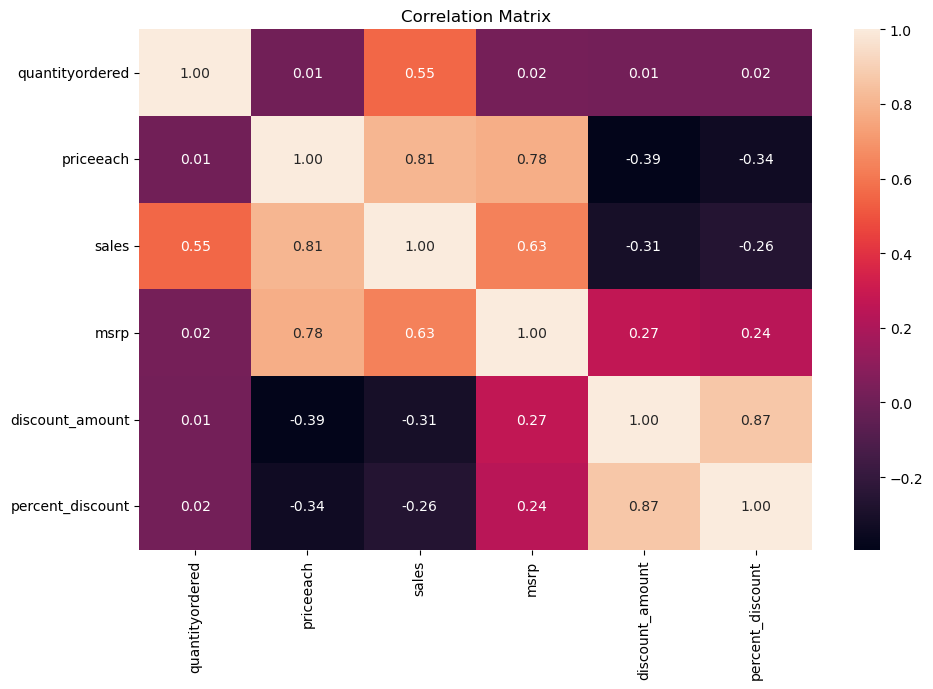

In [82]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [83]:
##largest transaction 
largest_transactions = (
    df[
        [
            "ordernumber",
            "customername",
            "productline",
            "quantityordered",
            "priceeach",
            "sales"
        ]
    ]
    .sort_values("sales", ascending=False)
)

largest_transactions.head(20)

,ordernumber,customername,productline,quantityordered,priceeach,sales
571,10407,The Sharp Gifts Warehouse,Vintage Cars,76,185.30,14082.80
714,10322,Online Diecast Creations Co.,Vintage Cars,50,250.73,12536.50
49,10424,Euro Shopping Channel,Classic Cars,50,240.02,12001.00
1020,10412,Euro Shopping Channel,Classic Cars,60,198.13,11887.80
96,10403,"UK Collectables, Ltd.",Motorcycles,66,180.10,11886.60
1930,10405,Mini Caravy,Classic Cars,76,154.47,11739.70
42,10312,Mini Gifts Distributors Ltd.,Classic Cars,48,242.16,11623.70
176,10127,Muscle Machine Inc,Classic Cars,46,245.20,11279.20
28,10150,"Dragon Souveniers, Ltd.",Classic Cars,45,244.30,10993.50
1779,10339,"Tokyo Collectables, Ltd",Vintage Cars,55,195.60,10758.00


In [84]:
##best selling product code
product_code_sales = (
    df.groupby("productcode")
      .agg(
          total_sales=("sales", "sum"),
          quantity_sold=("quantityordered", "sum"),
          order_lines=("ordernumber", "count")
      )
      .reset_index()
      .sort_values("total_sales", ascending=False)
)

product_code_sales.head(20)

,productcode,total_sales,quantity_sold,order_lines
39,S18_3232,284249.02,1754,51
1,S10_1949,179815.23,899,26
7,S12_1108,168585.32,973,26
3,S10_4698,158202.48,850,24
25,S18_2238,154623.95,966,27
12,S12_3891,145332.04,921,26
21,S18_1662,139421.97,940,26
76,S24_3856,135859.20,1017,26
47,S18_4027,133779.35,922,26
8,S12_1666,130466.79,919,26


## Key Findings

### Sales Performance
- Total sales:
- Total orders:
- Total customers:
- Average sales per order line:

### Time Trends
- Best-performing year:
- Lowest-performing year:
- Highest-sales month:
- Strongest quarter:

### Product Performance
- Highest-revenue product line:
- Highest-volume product line:
- Highest-average-price product line:

### Geographic Performance
- Top country:
- Top city:

### Customer Performance
- Top customer:
- Customer with highest order frequency:

### Pricing
- Average discount relative to MSRP:
- Product line with highest average discount:

### Operations
- Most common order status: